# Mock HI + 3D-dust observer: can the vertical trend be recovered?

An observer sitting near the **midplane** of the TIGRESS-NCR box looks out along
many Galactic $(l, b)$ directions (out to $\sim500$ pc, the 3D-dust regime).
Along each sightline we build, from the 3D cube,

* the 21 cm **emission** $T_B(v)$ and **absorption** $\tau(v)$ profiles
  (Kim, Ostriker & Kim 2014 radiative transfer; spin temperature $T_s=T_{\rm kin}$;
  same forward model as `astro_tigress.synthetic_HI`), and
* the **3D dust** differential extinction $dA_V/dd$ versus distance, assuming a
  constant dust-to-gas ratio $N_{\rm H}/A_V = 1.87\times10^{21}\,{\rm cm^{-2}\,mag^{-1}}$.

We keep sightlines with a **single** CNM absorption component *and* a **single**
dust structure, Gaussian-fit each, and ask: do the observer-recovered quantities,
placed at $z = d_0\sin b$, reproduce the **true** `cnm_zprof` vertical profiles?

## Method

For an isolated CNM component the **emission/absorption pair** gives the spin
temperature and column,

$$
T_s = \frac{T_B(v_0)}{1-e^{-\tau_0}}\ (\approx T_{\rm kin}),
\qquad
N_{\rm CNM} = 1.823\times10^{18}\,T_s\!\int\!\tau\,dv ,
$$

while the absorption **linewidth** gives the maximum kinetic temperature

$$
T_{k,\max} = \frac{m_{\rm H}\,(\Delta v)^2}{8k_B\ln2}
           = 21.86\,(\Delta v\,[{\rm km\,s^{-1}}])^2\ {\rm K}.
$$

The 3D dust Gaussian gives $(A_V, \Delta d, d_0)$, and the cloud height is
$z = z_{\rm obs} + d_0\sin b$.  Ground truth is the horizontally-averaged
`cnm_zprof` profile; note the plane-averaged $\sigma_{\rm eff,1D}$ mixes in
**cloud-to-cloud** motion, so its $T_{k,\max}=121.2\,\sigma_{\rm eff,1D}^2$ is an
upper envelope that a single-component observer should *not* reproduce.

## 1. Load the observer catalog and the true profiles

In [1]:
%matplotlib inline
import os
import glob
import os.path as osp
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

NCR = "/projects/EOSTRIKE/TIGRESS-NCR/R8_4pc_NCR.full.xy2048.eps0.np768.has/cnm_profiles"
FIGDIR = osp.join(NCR, "mock_obs", "figures")
os.makedirs(FIGDIR, exist_ok=True)

cat = np.load(osp.join(NCR, "mock_obs", "R8_4pc_NCR.mockobs.0300.npz"))
zc = cat["z"] / 1e3                                  # cloud height [kpc]
print(f"{len(zc)} single-component clouds, z = {zc.min():+.2f}..{zc.max():+.2f} kpc")

# true vertical profiles: median over the 31 NCR snapshots
files = sorted(glob.glob(osp.join(NCR, "R8_4pc_NCR.cnm_zprof.*.nc")))
comb = xr.concat([xr.open_dataset(f) for f in files], dim="ivtk")
tru = comb.median("ivtk")
zt = (comb["z"] / 1e3).values
T_true = tru["T"].values                             # mass-weighted CNM T(z)
nH_true = tru["nH"].values
Tkmax_plane = 121.2 * tru["sigma_eff_1D"].values ** 2  # plane-avg (cloud-to-cloud)
dv_plane = 2.3548 * tru["sigma_eff_1D"].values          # plane-avg FWHM

662 single-component clouds, z = -0.28..+0.20 kpc


## 2. Example sightlines: emission / absorption + 3D dust

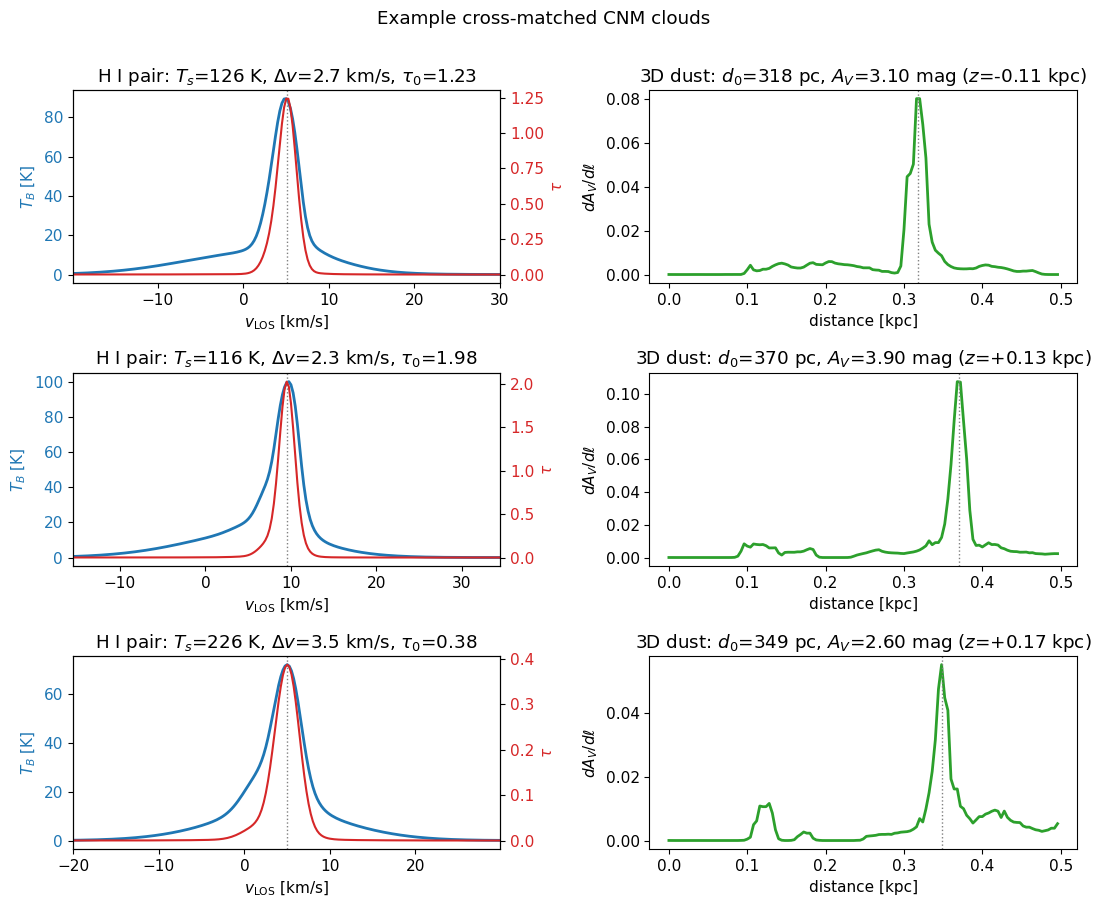

In [2]:
vchan, dgrid = cat["vchan"], cat["dgrid"]
nex = int(cat["n_examples"])
fig, axes = plt.subplots(nex, 2, figsize=(11, 3.0 * nex))
for j in range(nex):
    tau = cat[f"ex{j}_tau"]; TB = cat[f"ex{j}_TB"]; dA = cat[f"ex{j}_dA"]
    v0, tau0 = float(cat[f"ex{j}_v0"]), float(cat[f"ex{j}_tau0"])
    d0 = float(cat[f"ex{j}_d0"])
    a = axes[j, 0]
    a.plot(vchan, TB, "C0", lw=2, label=r"$T_B(v)$ (emission)")
    a.set_ylabel(r"$T_B$ [K]", color="C0"); a.tick_params(axis="y", labelcolor="C0")
    a2 = a.twinx()
    a2.plot(vchan, tau, "C3", lw=1.5, label=r"$\tau(v)$ (absorption)")
    a2.set_ylabel(r"$\tau$", color="C3"); a2.tick_params(axis="y", labelcolor="C3")
    a.axvline(v0, color="0.5", ls=":", lw=1)
    a.set_xlim(v0 - 25, v0 + 25); a.set_xlabel(r"$v_{\rm LOS}$ [km/s]")
    a.set_title(rf"H I pair: $T_s$={cat['Ts'][j]:.0f} K, "
                rf"$\Delta v$={cat['dv'][j]:.1f} km/s, $\tau_0$={tau0:.2f}")
    b = axes[j, 1]
    b.plot(dgrid / 1e3, dA, "C2", lw=2)
    b.axvline(d0 / 1e3, color="0.5", ls=":", lw=1)
    b.set_xlabel("distance [kpc]"); b.set_ylabel(r"$dA_V/d\ell$")
    b.set_title(rf"3D dust: $d_0$={d0:.0f} pc, $A_V$={cat['A_V'][j]:.2f} mag "
                rf"($z$={cat['z'][j] / 1e3:+.2f} kpc)")
fig.suptitle("Example cross-matched CNM clouds", y=1.005)
fig.tight_layout()
fig.savefig(osp.join(FIGDIR, "mockobs_examples.png"), dpi=150, bbox_inches="tight")

## 3. Recovering the vertical trend

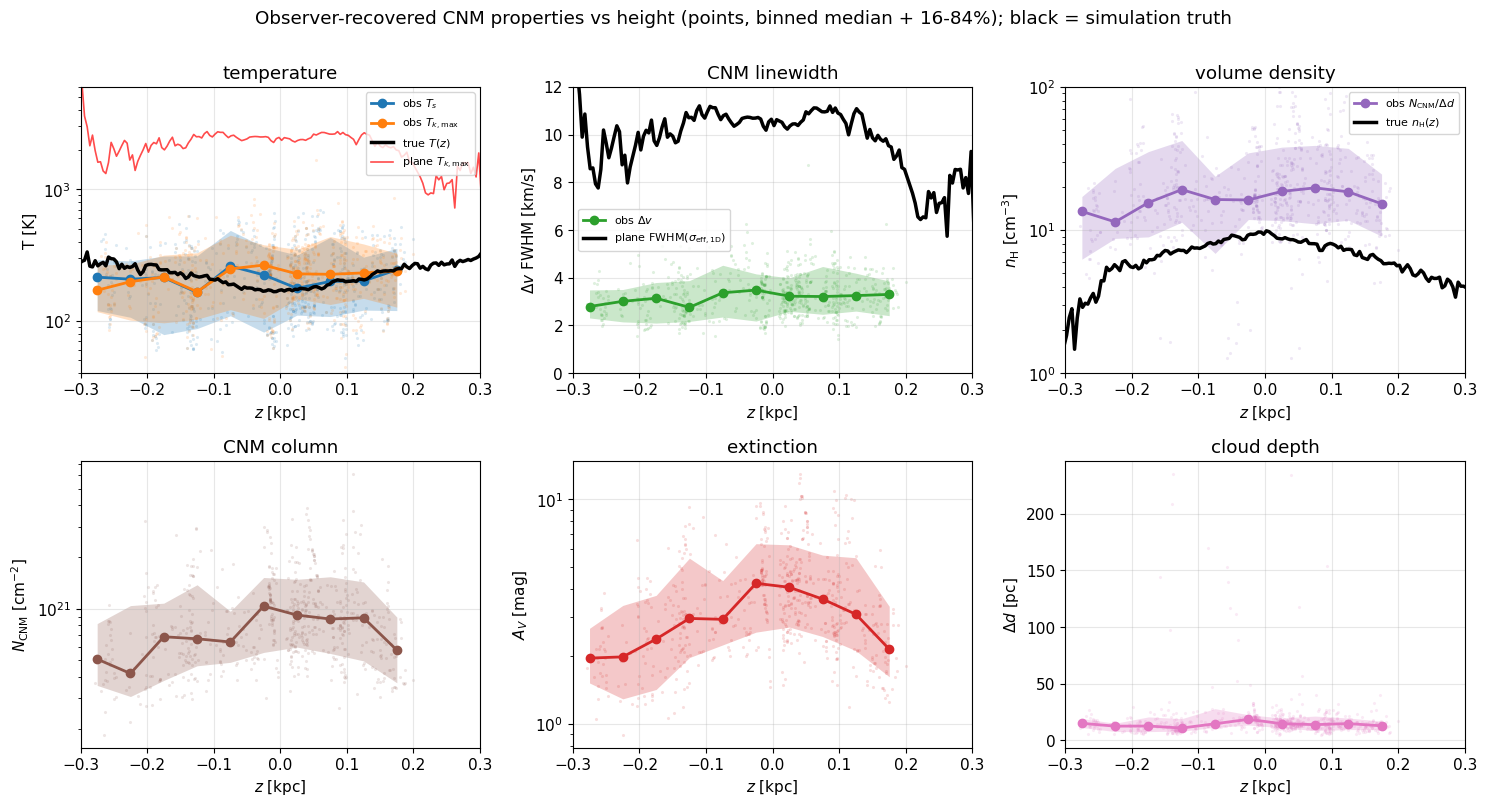

In [3]:
def binstat(z, q, bins):
    # median and 16-84 percentile of q(z) in z-bins (>=3 clouds per bin)
    bc = 0.5 * (bins[1:] + bins[:-1])
    med = np.full(len(bc), np.nan); lo = med.copy(); hi = med.copy()
    for i in range(len(bc)):
        m = (z >= bins[i]) & (z < bins[i + 1]) & np.isfinite(q)
        if m.sum() >= 3:
            med[i] = np.median(q[m]); lo[i], hi[i] = np.percentile(q[m], [16, 84])
    return bc, med, lo, hi


def obs_panel(ax, q, color, label, logy=False):
    ax.scatter(zc, q, s=5, c=color, alpha=0.15, lw=0)
    bc, m, lo, hi = binstat(zc, q, bins)
    ax.fill_between(bc, lo, hi, color=color, alpha=0.25, lw=0)
    ax.plot(bc, m, "o-", color=color, lw=2, label=label)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(r"$z$ [kpc]"); ax.set_xlim(-0.3, 0.3); ax.grid(alpha=0.3)


bins = np.linspace(-0.3, 0.3, 13)
PC = 3.0857e18
n_obs = cat["N_CNM"] / (cat["dd"] * PC)              # N_CNM / depth -> volume density

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# (a) temperature: T_s and T_kmax vs true T(z) and the plane-averaged T_kmax
obs_panel(ax[0, 0], cat["Ts"], "C0", r"obs $T_s$", logy=True)
obs_panel(ax[0, 0], cat["Tkmax"], "C1", r"obs $T_{k,\max}$", logy=True)
ax[0, 0].plot(zt, T_true, "k-", lw=2.5, label=r"true $T(z)$")
ax[0, 0].plot(zt, Tkmax_plane, "r-", lw=1.2, alpha=0.7,
              label=r"plane $T_{k,\max}$")
ax[0, 0].set_ylabel("T [K]"); ax[0, 0].set_ylim(40, 6000)
ax[0, 0].set_title("temperature"); ax[0, 0].legend(fontsize=8)

# (b) linewidth: observed per-cloud vs plane-averaged FWHM
obs_panel(ax[0, 1], cat["dv"], "C2", r"obs $\Delta v$")
ax[0, 1].plot(zt, dv_plane, "k-", lw=2.5, label=r"plane FWHM($\sigma_{\rm eff,1D}$)")
ax[0, 1].set_ylabel(r"$\Delta v$ FWHM [km/s]"); ax[0, 1].set_ylim(0, 12)
ax[0, 1].set_title("CNM linewidth"); ax[0, 1].legend(fontsize=8)

# (c) volume density: observer N_CNM/dd vs true nH(z)
obs_panel(ax[0, 2], n_obs, "C4", r"obs $N_{\rm CNM}/\Delta d$", logy=True)
ax[0, 2].plot(zt, nH_true, "k-", lw=2.5, label=r"true $n_{\rm H}(z)$")
ax[0, 2].set_ylabel(r"$n_{\rm H}$ [cm$^{-3}$]"); ax[0, 2].set_ylim(1, 100)
ax[0, 2].set_title("volume density"); ax[0, 2].legend(fontsize=8)

# (d) CNM column density
obs_panel(ax[1, 0], cat["N_CNM"], "C5", r"obs $N_{\rm CNM}$", logy=True)
ax[1, 0].set_ylabel(r"$N_{\rm CNM}$ [cm$^{-2}$]"); ax[1, 0].set_title("CNM column")

# (e) extinction
obs_panel(ax[1, 1], cat["A_V"], "C3", r"obs $A_V$", logy=True)
ax[1, 1].set_ylabel(r"$A_V$ [mag]"); ax[1, 1].set_title("extinction")

# (f) cloud depth
obs_panel(ax[1, 2], cat["dd"], "C6", r"obs $\Delta d$")
ax[1, 2].set_ylabel(r"$\Delta d$ [pc]"); ax[1, 2].set_title("cloud depth")

fig.suptitle("Observer-recovered CNM properties vs height (points, binned median "
             "+ 16-84%); black = simulation truth", y=1.005)
fig.tight_layout()
fig.savefig(osp.join(FIGDIR, "mockobs_vs_z.png"), dpi=150, bbox_inches="tight")

## 4. Sky maps of the fitted results

The fitted clouds for a **single** observer, shown on **zenithal equal-area**
(Lambert azimuthal) sky maps — one per hemisphere.  The pole ($|b|=90^\circ$,
straight up/down) is at the center, Galactic longitude $l$ is the azimuth, and
the radius is the equal-area co-latitude $r = 2\sin[(90^\circ-|b|)/2]$ (rings
mark $b=20,40,60,80^\circ$).

78 clouds in the single-observer sky (27 north, 51 south)


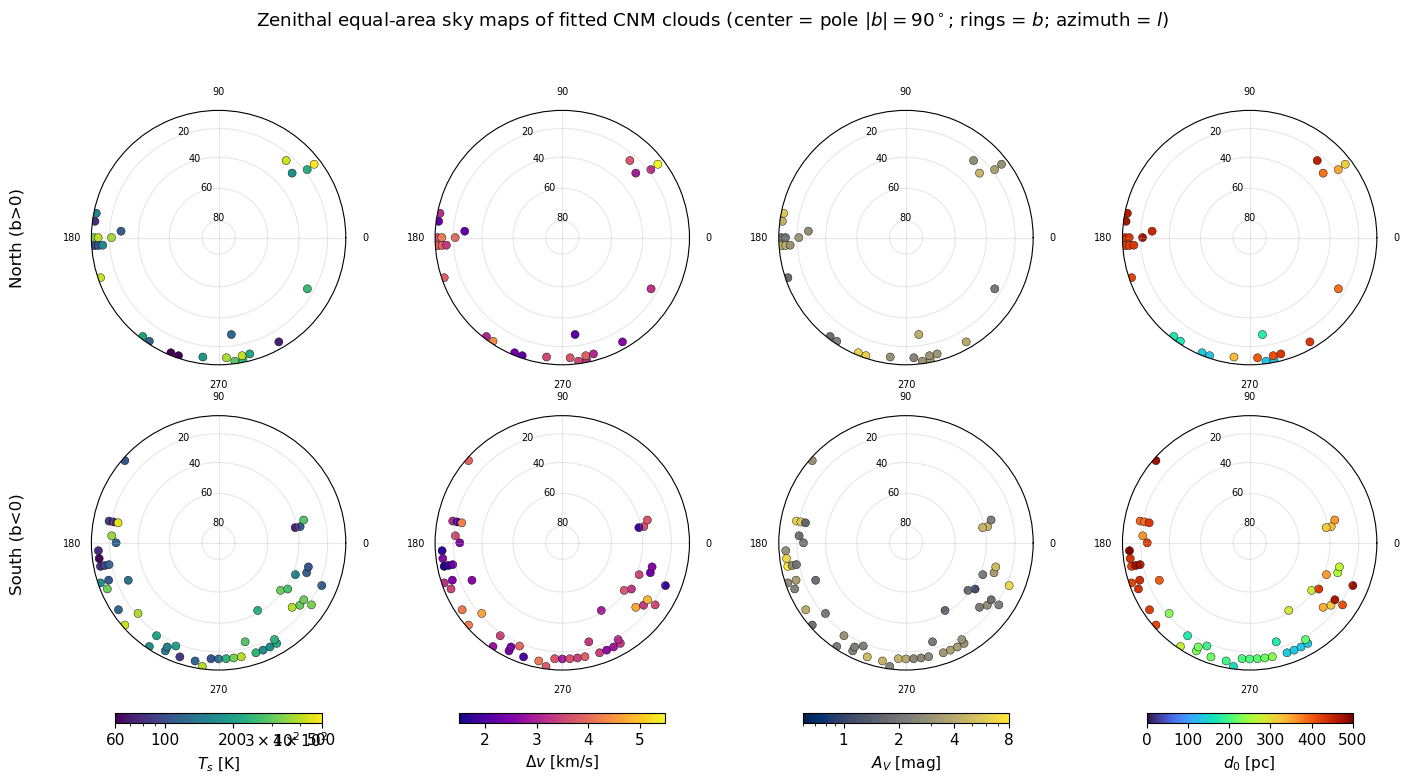

In [4]:
import matplotlib.colors as mcolors

# single-observer catalog (one sky = one observer)
mcat = np.load(osp.join(NCR, "mock_obs", "R8_4pc_NCR.mockobs_map.0300.npz"))
ml, mb = mcat["l"], mcat["b"]
print(f"{len(ml)} clouds in the single-observer sky "
      f"({(mb > 0).sum()} north, {(mb < 0).sum()} south)")


def skymap(ax, l, b, c, vmn, vmx, cmap, logc, s=34):
    th = np.deg2rad(l)
    r = 2 * np.sin(np.deg2rad(90 - np.abs(b)) / 2)     # Lambert equal-area radius
    norm = mcolors.LogNorm(vmn, vmx) if logc else mcolors.Normalize(vmn, vmx)
    sc = ax.scatter(th, r, c=c, s=s, cmap=cmap, norm=norm, edgecolor="k", lw=0.3)
    bt = np.array([20, 40, 60, 80])
    ax.set_rgrids(2 * np.sin(np.deg2rad(90 - bt) / 2), labels=[str(v) for v in bt],
                  fontsize=7, angle=112)
    ax.set_rmax(2 * np.sin(np.deg2rad(90 - 6) / 2))
    ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    ax.set_xticklabels(["0", "90", "180", "270"], fontsize=7)
    ax.grid(alpha=0.3)
    return sc


qs = [("Ts", r"$T_s$ [K]", "viridis", True, 60, 500, [60, 100, 200, 500]),
      ("dv", r"$\Delta v$ [km/s]", "plasma", False, 1.5, 5.5, [2, 3, 4, 5]),
      ("A_V", r"$A_V$ [mag]", "cividis", True, 0.6, 8.0, [1, 2, 4, 8]),
      ("d0", r"$d_0$ [pc]", "turbo", False, 0, 500, [0, 100, 200, 300, 400, 500])]
fig, axes = plt.subplots(2, 4, figsize=(17, 9.2),
                         subplot_kw=dict(projection="polar"))
for col, (q, lab, cmap, logc, vmn, vmx, ticks) in enumerate(qs):
    for row, (sel, hemi) in enumerate([(mb > 0, "North (b>0)"),
                                       (mb < 0, "South (b<0)")]):
        sc = skymap(axes[row, col], ml[sel], mb[sel], mcat[q][sel],
                    vmn, vmx, cmap, logc)
        if col == 0:
            axes[row, col].annotate(hemi, xy=(-0.32, 0.5), xycoords="axes fraction",
                                    rotation=90, va="center", fontsize=12)
    cb = fig.colorbar(sc, ax=[axes[0, col], axes[1, col]], location="bottom",
                      shrink=0.72, pad=0.06, label=lab)
    cb.set_ticks(ticks)
    cb.set_ticklabels([str(t) for t in ticks])
fig.suptitle(r"Zenithal equal-area sky maps of fitted CNM clouds "
             r"(center = pole $|b|=90^\circ$; rings = $b$; azimuth = $l$)", y=0.99)
fig.savefig(osp.join(FIGDIR, "mockobs_skymaps.png"), dpi=150, bbox_inches="tight")

## 5. What the experiment shows

* **The temperature trend is recovered.** The emission/absorption spin
  temperature $T_s(z)$ tracks the true mass-weighted $T(z)\sim200$ K, and for
  these single, isolated CNM components the linewidth-based $T_{k,\max}(z)$ sits
  just above $T_s$ — i.e. the selected clouds are close to thermal.
* **The plane-averaged $T_{k,\max}$ is *not* what an observer measures.** It is
  $\sim10$–15$\times$ higher (red) because the horizontal average folds in
  **cloud-to-cloud** motion; a real per-sightline CNM line is much narrower
  ($\Delta v\sim3$ vs $\sim10$ km/s).
* **Density / column / extinction decline with $|z|$** as expected, so the
  vertical *structure* of the cold layer is recoverable from the mock
  observations under a constant dust-to-gas ratio.

Caveats: single snapshot; spin temperature $T_s=T_{\rm kin}$ (thermalized CNM);
optically-thin dust with constant $N_{\rm H}/A_V$; sightlines capped at 500 pc
with periodic $x,y$ wrapping (shear-wrap approximated); WNM blending in $T_s$ is
not deblended. See `scripts/mock_hi_dust_observer.py`.